In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn')
%config InlineBackend.figure_format = 'retina'

import os
import re
import warnings
warnings.filterwarnings('ignore')

In [266]:
pokemon = pd.read_csv('C:\\Users\\Lee\\Desktop\\GIt\\AIFFEL_first\\FUNDAMENTALS\\pokemon\\pokemon.csv')

In [267]:
pokemon.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [268]:
print(pokemon.shape)
pokemon.info()

(800, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [269]:
legendary = pokemon[pokemon.Legendary==True].reset_index(drop=True)
ordinary = pokemon[pokemon.Legendary==False].reset_index(drop=True)

In [270]:
legendary

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,144,Articuno,Ice,Flying,580,90,85,100,95,125,85,1,True
1,145,Zapdos,Electric,Flying,580,90,90,85,125,90,100,1,True
2,146,Moltres,Fire,Flying,580,90,100,90,125,85,90,1,True
3,150,Mewtwo,Psychic,NaN,680,106,110,90,154,90,130,1,True
4,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
61,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
62,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
63,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [271]:
ordinary

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,711,GourgeistSuper Size,Ghost,Grass,494,85,100,122,58,75,54,6,False
731,712,Bergmite,Ice,NaN,304,55,69,85,32,35,28,6,False
732,713,Avalugg,Ice,NaN,514,95,117,184,44,46,28,6,False
733,714,Noibat,Flying,Dragon,245,40,30,35,45,40,55,6,False


# EDA

In [272]:
pokemon.isnull().sum()

#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [273]:
pokemon.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

- \# :포켓몬 Id number. 성별이 다르지만 같은 포켓몬인 경우 등은 같은 #값을 가진다. int
- Name : 포켓몬 이름. 포켓몬 각각의 이름으로 저장되고, 800개의 포켓몬의 이름 데이터는 모두 다르다. (unique) str
- Type 1 : 첫 번째 속성. 속성을 하나만 가지는 경우 Type 1에 입력된다. str
- Type 2 : 두 번째 속성. 속성을 하나만 가지는 포켓몬의 경우 Type 2는 NaN(결측값)을 가진다. str
- Total : 전체 6가지 스탯의 총합. int
- HP : 포켓몬의 체력. int
- Attack : 물리 공격력. (scratch, punch 등) int
- Defense : 물리 공격에 대한 방어력. int
- Sp. Atk : 특수 공격력. (fire blast, bubble beam 등) int
- Sp. Def : 특수 공격에 대한 방어력. int
- Speed : 포켓몬 매치에 대해 어떤 포켓몬이 먼저 공격할지를 결정. (더 높은 포켓몬이 먼저 공격한다) int
- Generation : 포켓몬의 세대. 현재 데이터에는 6세대까지 있다. int
- Legendary : 전설의 포켓몬 여부. !! Target feature !! bool

In [274]:
pokemon[pokemon[['#']].duplicated()]['#'].values

array([  3,   6,   6,   9,  15,  18,  65,  80,  94, 115, 127, 130, 142,
       150, 150, 181, 208, 212, 214, 229, 248, 254, 257, 260, 282, 302,
       303, 306, 308, 310, 319, 323, 334, 354, 359, 362, 373, 376, 380,
       381, 382, 383, 384, 386, 386, 386, 413, 413, 428, 445, 448, 460,
       475, 479, 479, 479, 479, 479, 487, 492, 531, 555, 641, 642, 645,
       646, 646, 647, 648, 678, 681, 710, 710, 710, 711, 711, 711, 719,
       720], dtype=int64)

In [275]:
pokemon[['#']].drop_duplicates()

,#
0,1
1,2
2,3
4,4
5,5
...,...
793,717
794,718
795,719
797,720


## Type

In [276]:
print(pokemon['Type 1'].nunique(),pokemon['Type 2'].nunique())
print(len(list(set(pokemon['Type 1']))),len(list(set(pokemon['Type 2'])))) # len은 nan까지 count

18 18
18 19


In [277]:
set(pokemon["Type 2"]) - set(pokemon["Type 1"])

{nan}

In [278]:
pokemon['Type 2'].isna().sum()

386

Text(0.5, 1.0, 'Legendary')

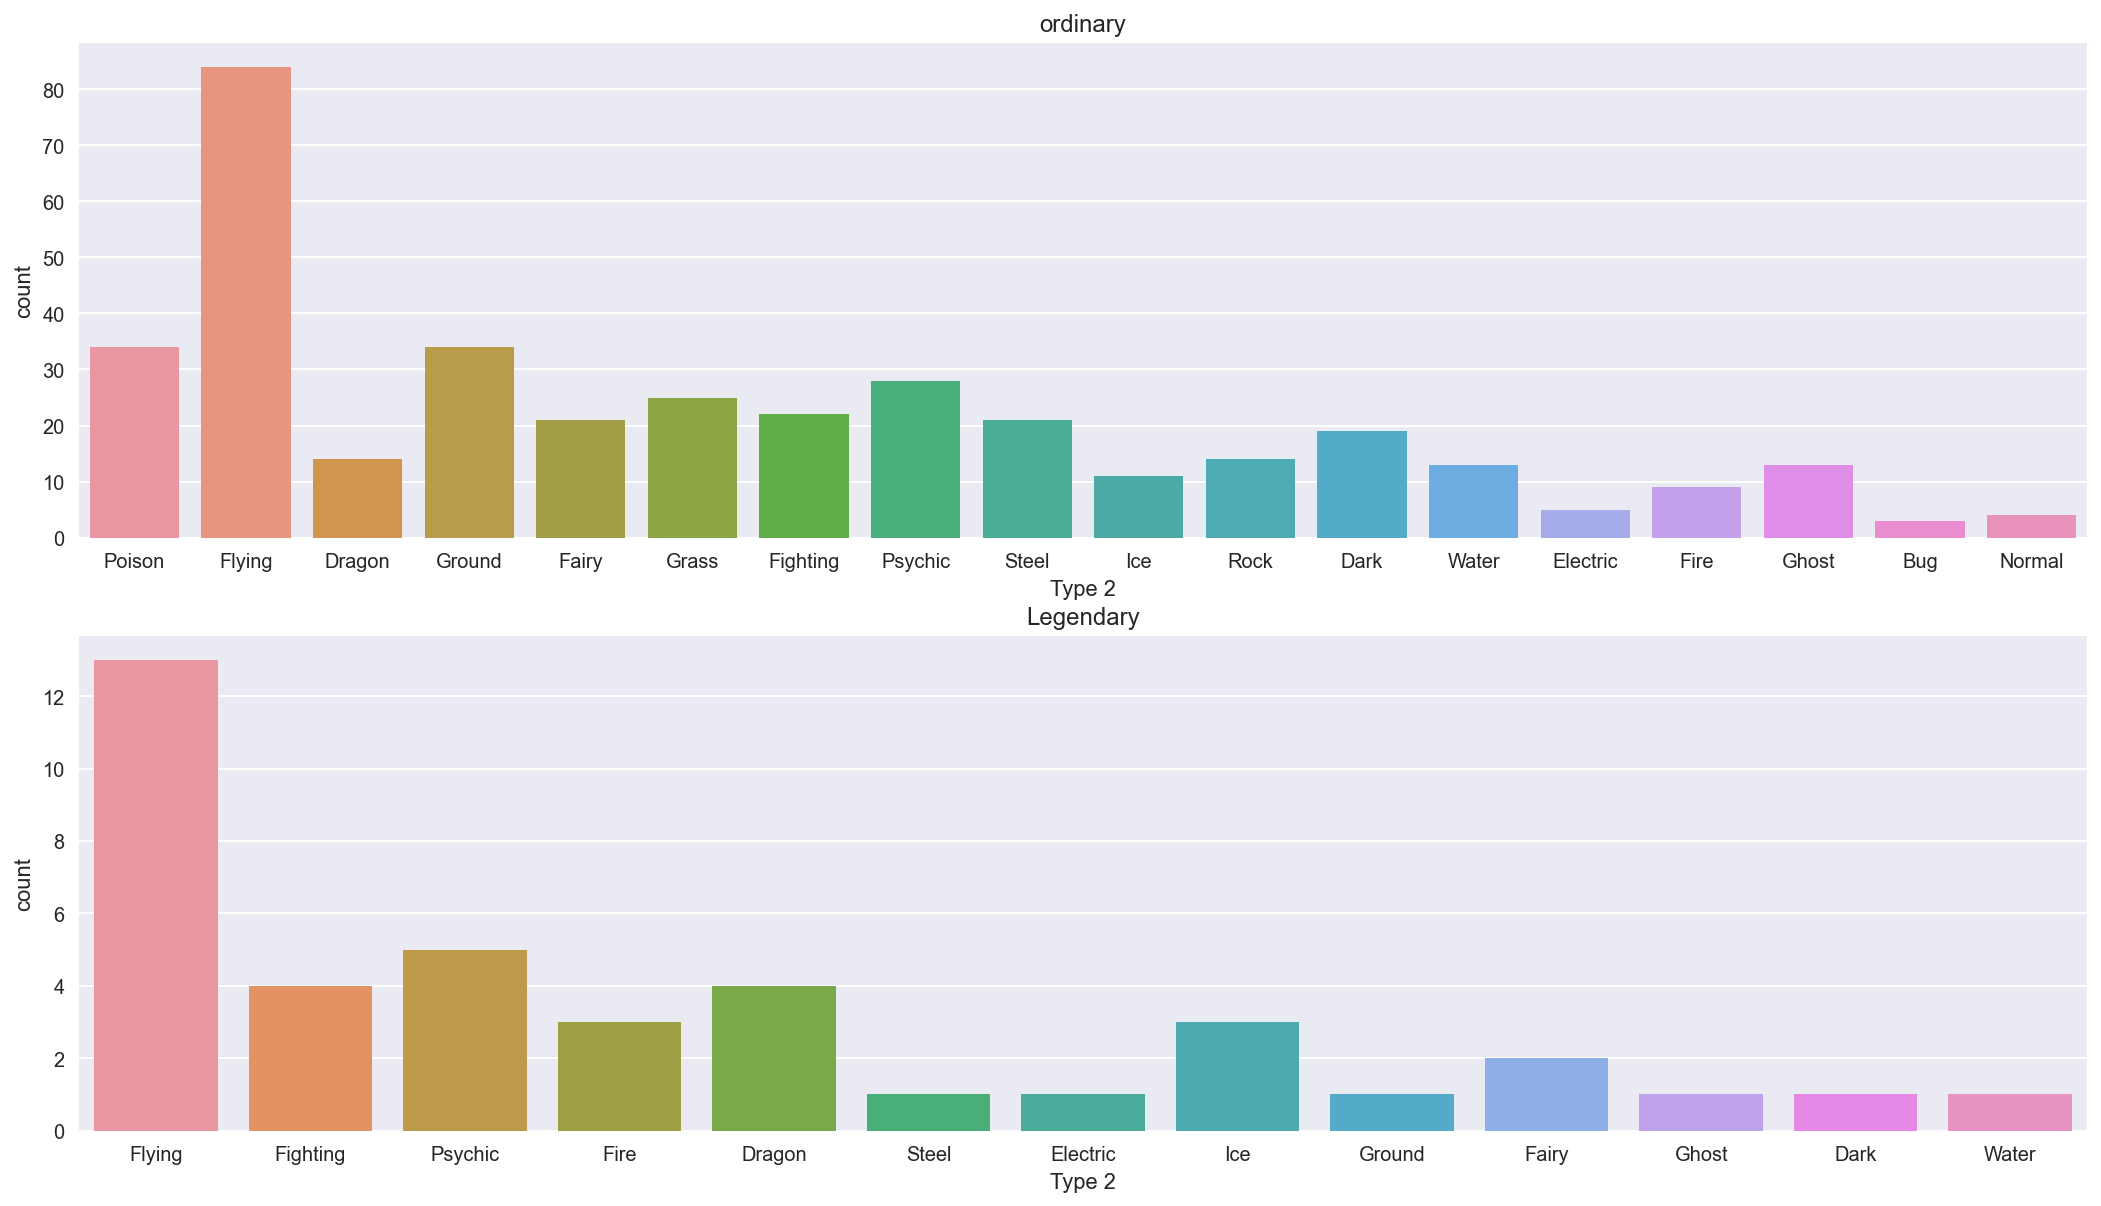

In [279]:
f , ax = plt.subplots(2,1,figsize=(18,10))

sns.countplot(data=ordinary,x='Type 2',ax=ax[0]).set_title('ordinary')
sns.countplot(data=legendary,x='Type 2',ax=ax[1]).set_title('Legendary')

In [280]:
legendary[legendary['Type 2'] =='Flying']

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,144,Articuno,Ice,Flying,580,90,85,100,95,125,85,1,True
1,145,Zapdos,Electric,Flying,580,90,90,85,125,90,100,1,True
2,146,Moltres,Fire,Flying,580,90,100,90,125,85,90,1,True
9,249,Lugia,Psychic,Flying,680,106,90,130,90,154,110,2,True
10,250,Ho-oh,Fire,Flying,680,106,130,90,110,154,90,2,True
22,384,Rayquaza,Dragon,Flying,680,105,150,90,150,90,95,3,True
23,384,RayquazaMega Rayquaza,Dragon,Flying,780,105,180,100,180,100,115,3,True
40,492,ShayminSky Forme,Grass,Flying,600,100,103,75,120,75,127,4,True
48,642,ThundurusIncarnate Forme,Electric,Flying,580,79,115,70,125,80,111,5,True
49,642,ThundurusTherian Forme,Electric,Flying,580,79,105,70,145,80,101,5,True


In [281]:
pd.pivot_table(pokemon, index="Type 1", values="Legendary").sort_values(by=["Legendary"], ascending=False)
 # 각 type별 전설포켓몬 비율

,Legendary
Type 1,
Flying,0.500000
Dragon,0.375000
Psychic,0.245614
Steel,0.148148
Ground,0.125000
Fire,0.096154
Electric,0.090909
Rock,0.090909
Ice,0.083333


In [282]:
pokemon['Type 1'].unique()

array(['Grass', 'Fire', 'Water', 'Bug', 'Normal', 'Poison', 'Electric',
       'Ground', 'Fairy', 'Fighting', 'Psychic', 'Rock', 'Ghost', 'Ice',
       'Dragon', 'Dark', 'Steel', 'Flying'], dtype=object)

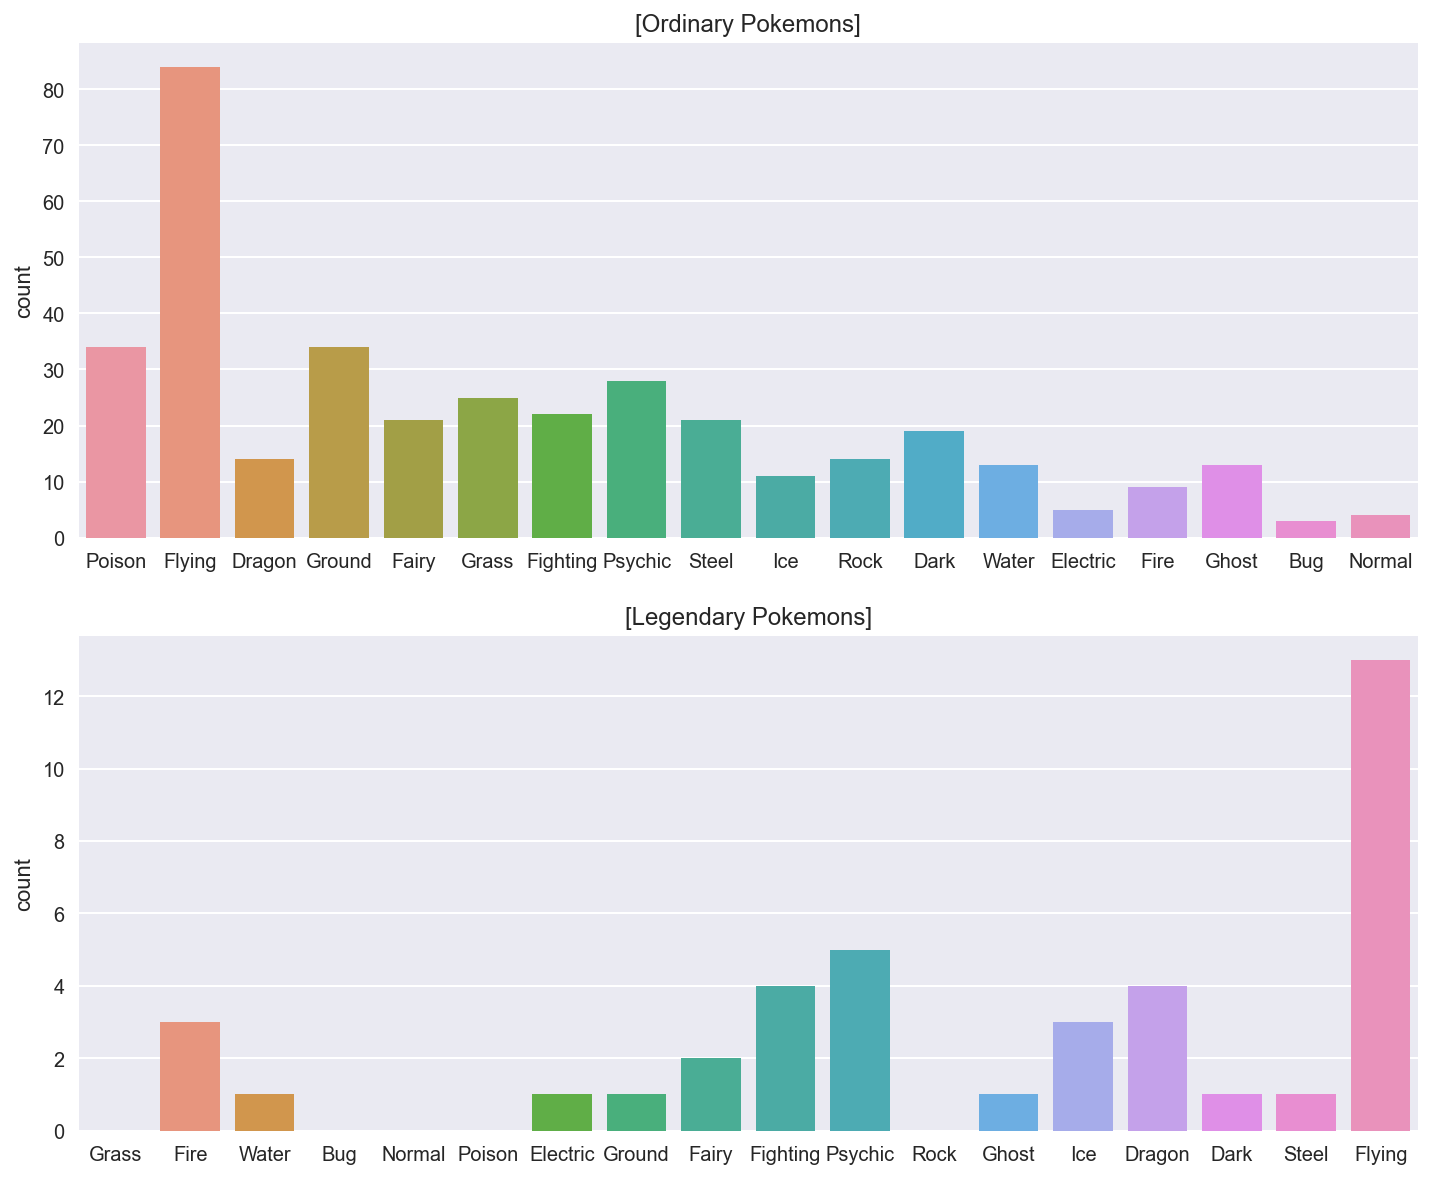

In [283]:
plt.figure(figsize=(12, 10))  # 화면 해상도에 따라 그래프 크기를 조정해 주세요.

plt.subplot(211)
sns.countplot(data=ordinary, x="Type 2").set_xlabel('')
plt.title("[Ordinary Pokemons]")

plt.subplot(212)
sns.countplot(data=legendary, x="Type 2", order=pokemon['Type 1'].unique()).set_xlabel('')
plt.title("[Legendary Pokemons]")

plt.show()



### Total

In [284]:
stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

<AxesSubplot:xlabel='Type 1', ylabel='Total'>

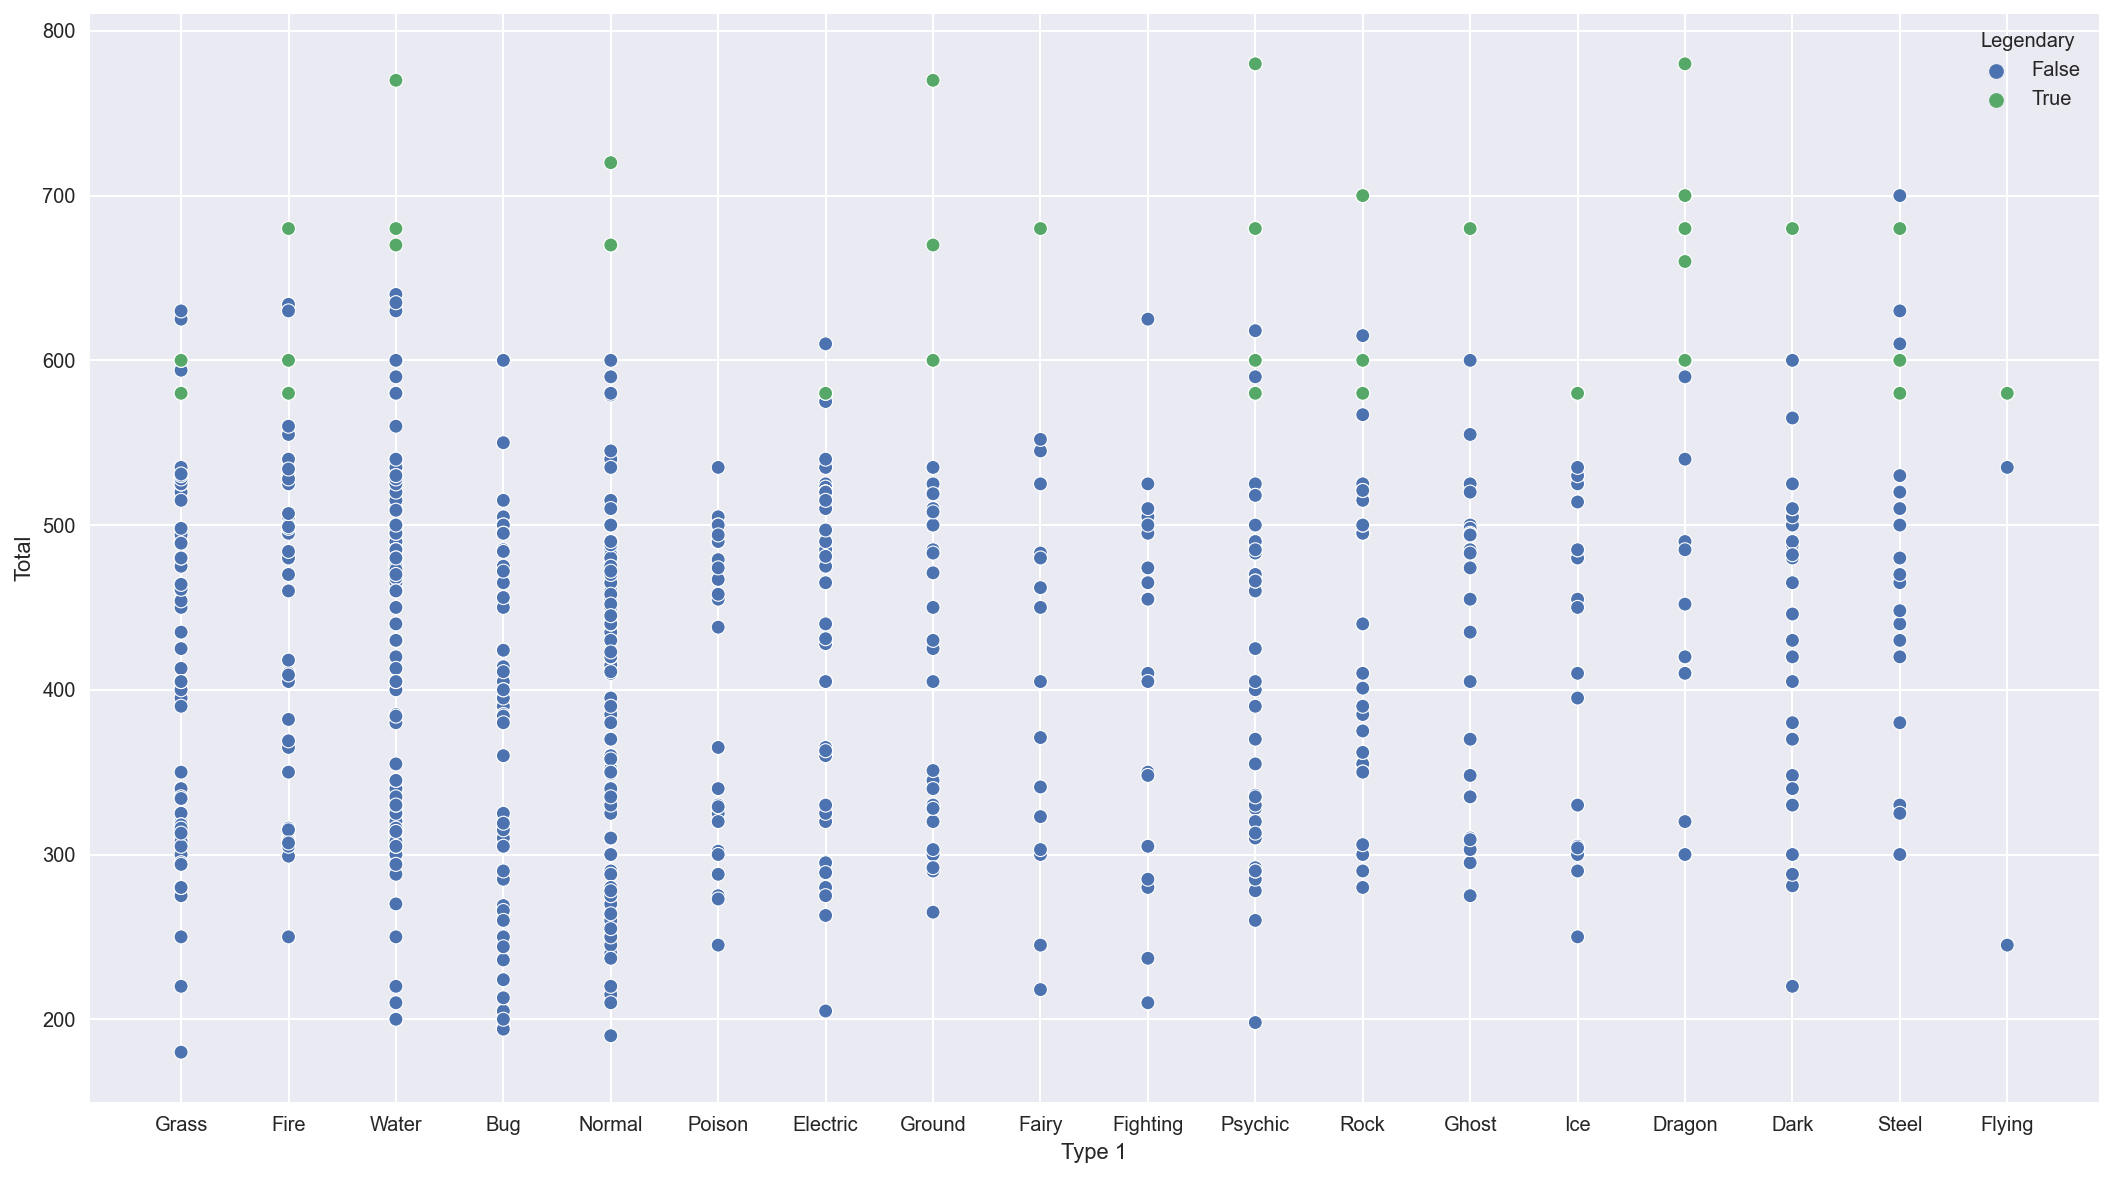

In [285]:
plt.figure(figsize=(18,10))
sns.scatterplot(data=pokemon , x ='Type 1',y = 'Total',hue = 'Legendary')

- 전설포켓몬 전체적 스텟이 높다

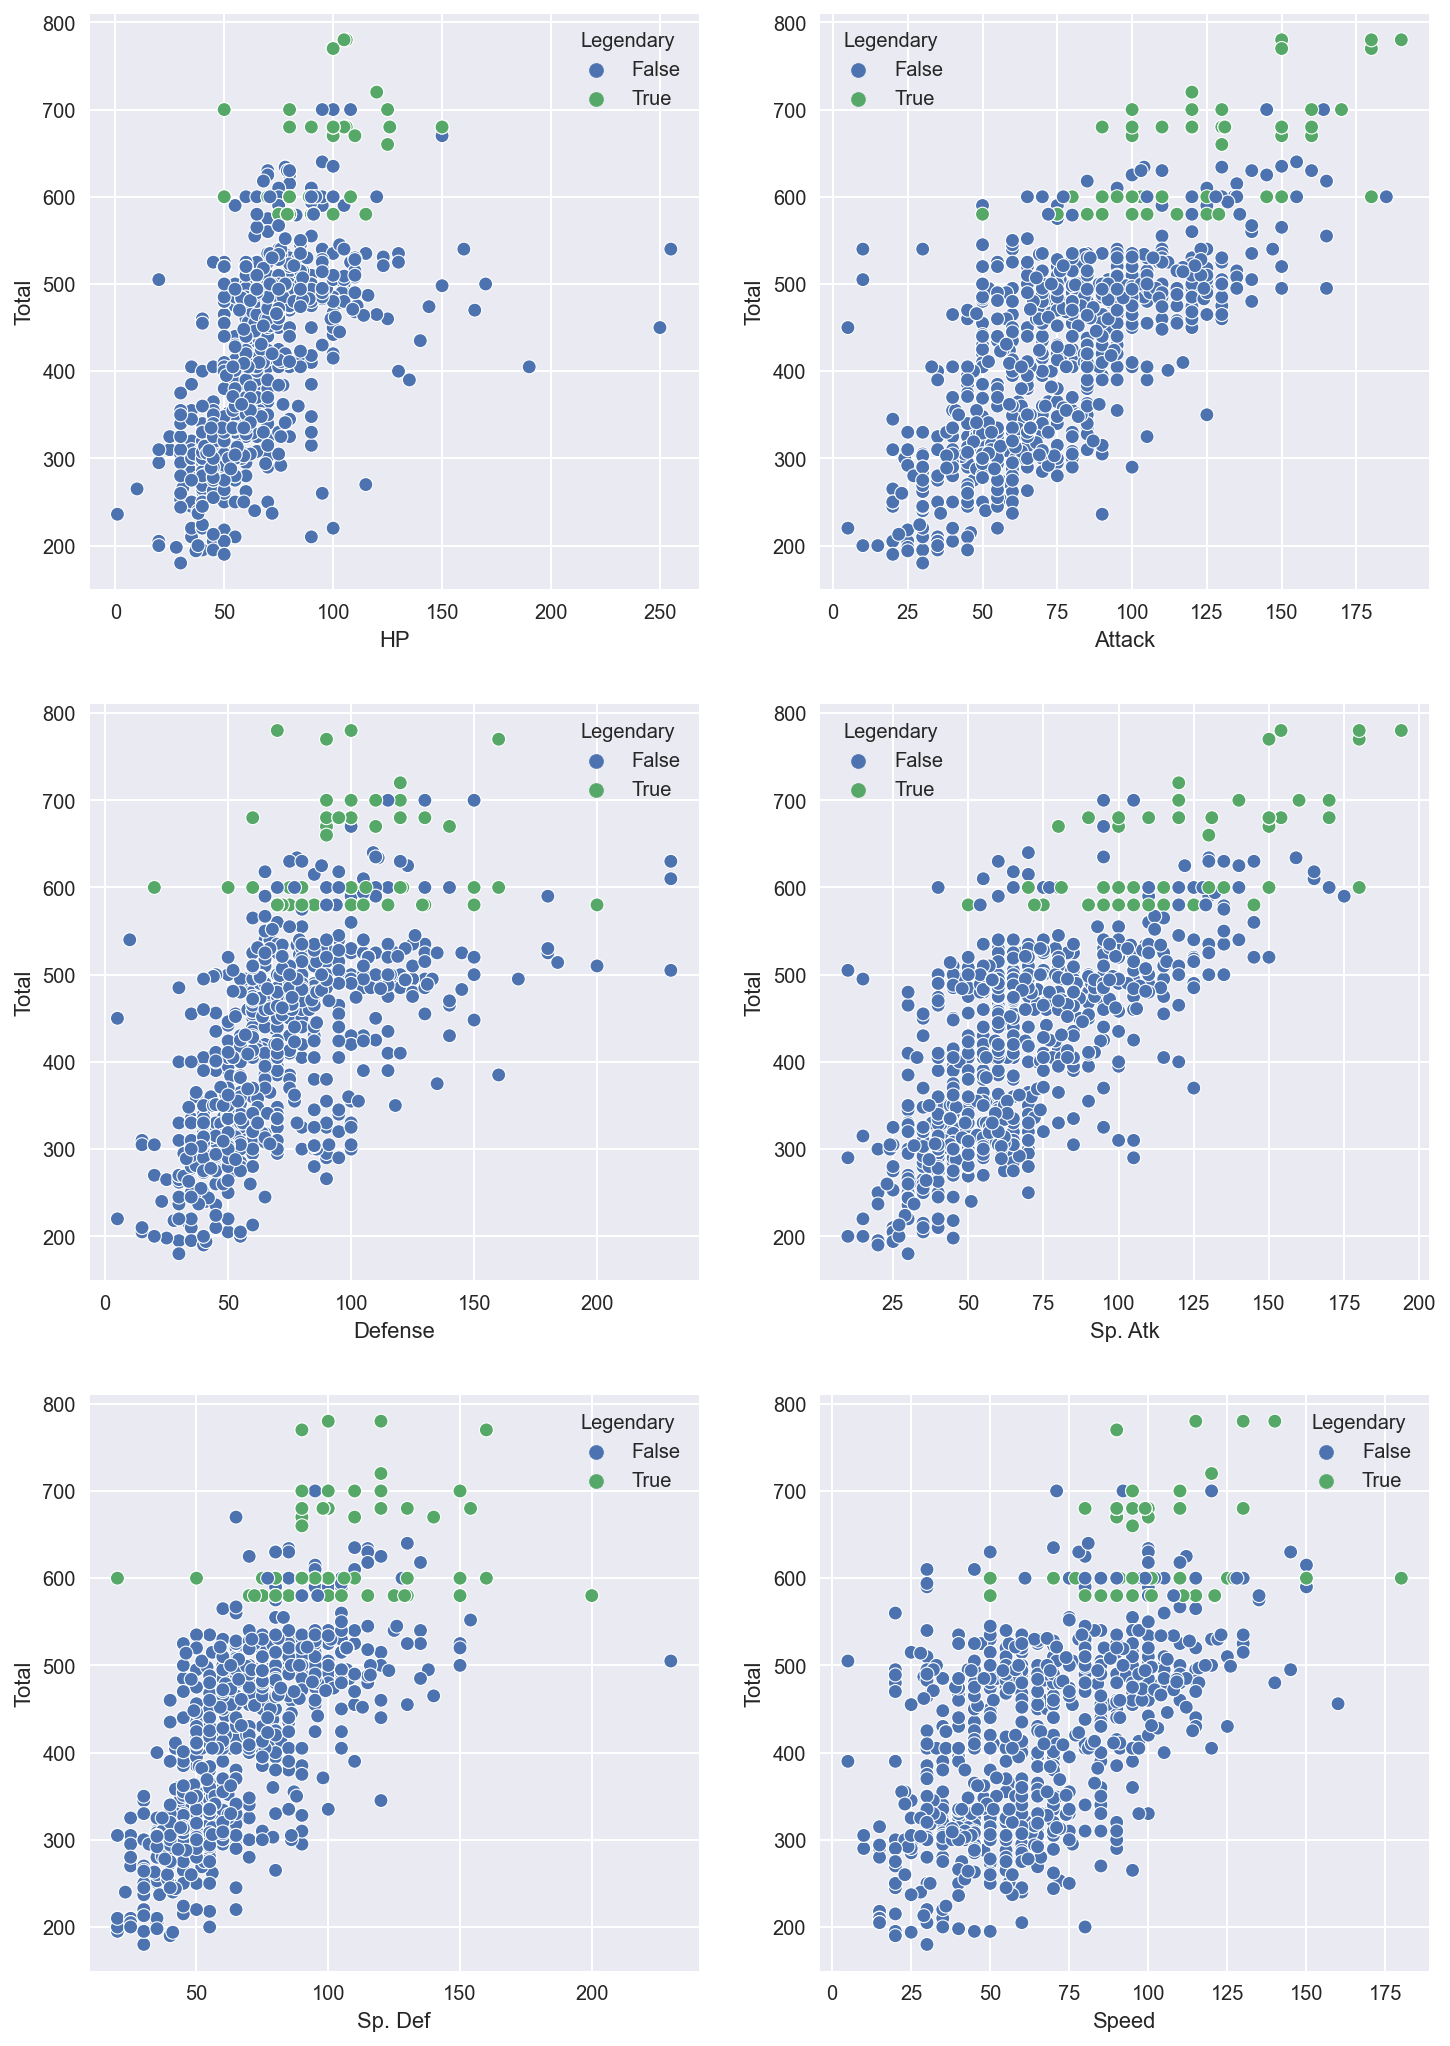

In [286]:
figure, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(nrows=3, ncols=2)
figure.set_size_inches(12, 18)  # 화면 해상도에 따라 그래프 크기를 조정해 주세요.

sns.scatterplot(data=pokemon, y="Total", x="HP", hue="Legendary", ax=ax1)
sns.scatterplot(data=pokemon, y="Total", x="Attack", hue="Legendary", ax=ax2)
sns.scatterplot(data=pokemon, y="Total", x="Defense", hue="Legendary", ax=ax3)
sns.scatterplot(data=pokemon, y="Total", x="Sp. Atk", hue="Legendary", ax=ax4)
sns.scatterplot(data=pokemon, y="Total", x="Sp. Def", hue="Legendary", ax=ax5)
sns.scatterplot(data=pokemon, y="Total", x="Speed", hue="Legendary", ax=ax6)
plt.show()

<AxesSubplot:xlabel='Total', ylabel='Type 1'>

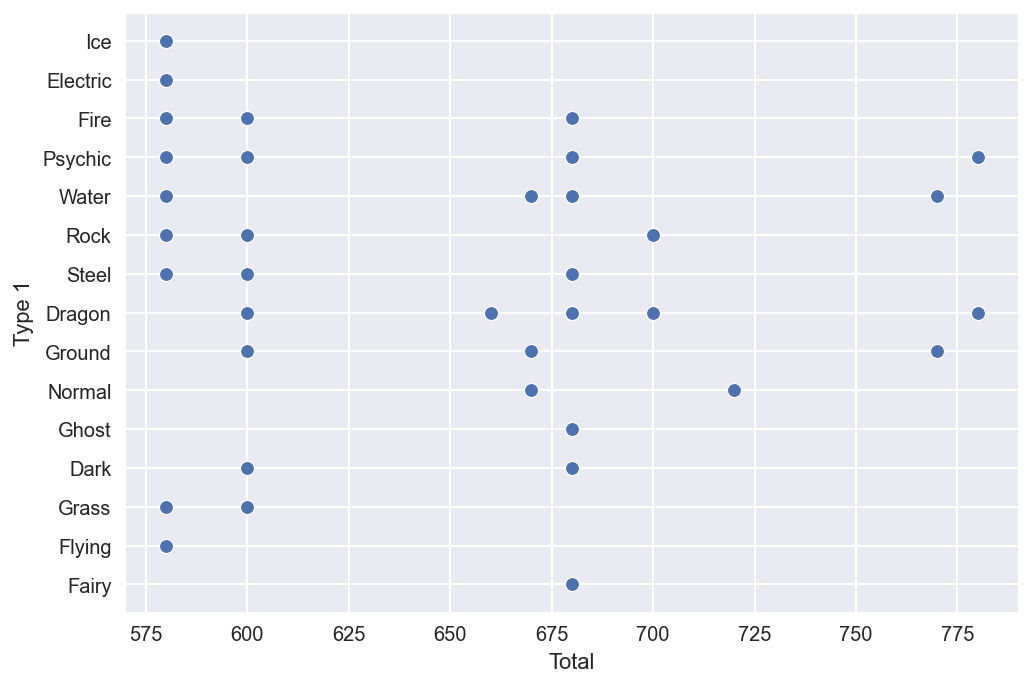

In [287]:
sns.scatterplot(data=legendary , x = 'Total',y = 'Type 1')

In [288]:
legendary.Total.unique()

array([580, 680, 780, 600, 700, 670, 770, 720, 660], dtype=int64)

### Generation

Text(0.5, 1.0, 'legendary')

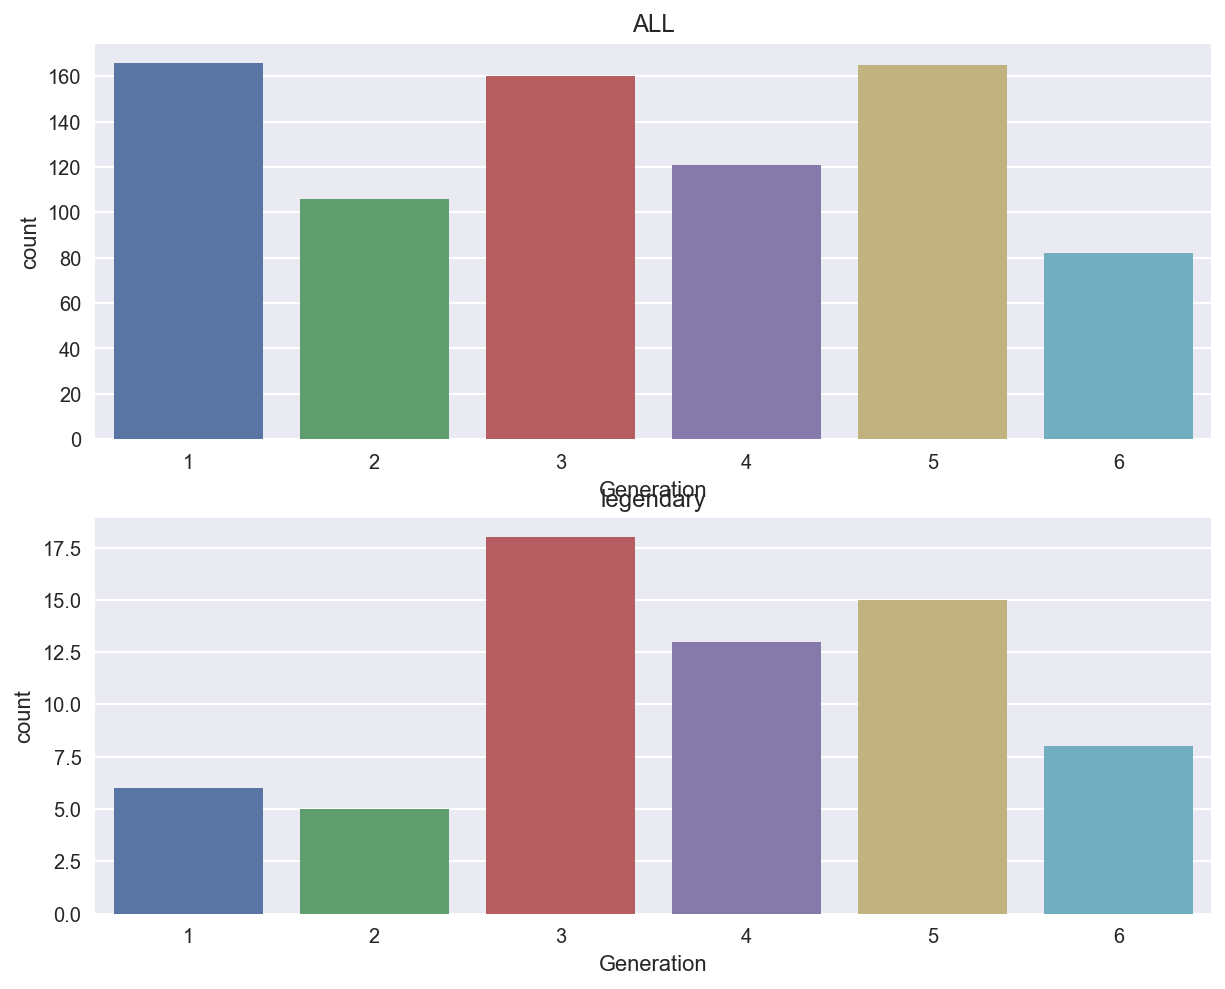

In [289]:
plt.figure(figsize=(10,8))
plt.subplot(211)
sns.countplot(data = pokemon , x ='Generation').set_title('ALL')
plt.subplot(212)
sns.countplot(data = legendary , x ='Generation').set_title('legendary')

### Name

In [290]:
pokemon.Name.nunique()

800

In [291]:
legendary['Name_len']=legendary['Name'].apply(lambda x :len(x))
ordinary['Name_len']=ordinary['Name'].apply(lambda x :len(x))

In [292]:
legendary

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Name_len
0,144,Articuno,Ice,Flying,580,90,85,100,95,125,85,1,True,8
1,145,Zapdos,Electric,Flying,580,90,90,85,125,90,100,1,True,6
2,146,Moltres,Fire,Flying,580,90,100,90,125,85,90,1,True,7
3,150,Mewtwo,Psychic,NaN,680,106,110,90,154,90,130,1,True,6
4,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True,7
61,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True,19
62,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True,19
63,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True,18


In [293]:
ordinary

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Name_len
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,9
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,7
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,8
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,21
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,711,GourgeistSuper Size,Ghost,Grass,494,85,100,122,58,75,54,6,False,19
731,712,Bergmite,Ice,NaN,304,55,69,85,32,35,28,6,False,8
732,713,Avalugg,Ice,NaN,514,95,117,184,44,46,28,6,False,7
733,714,Noibat,Flying,Dragon,245,40,30,35,45,40,55,6,False,6


Text(0.5, 1.0, 'ordinary')

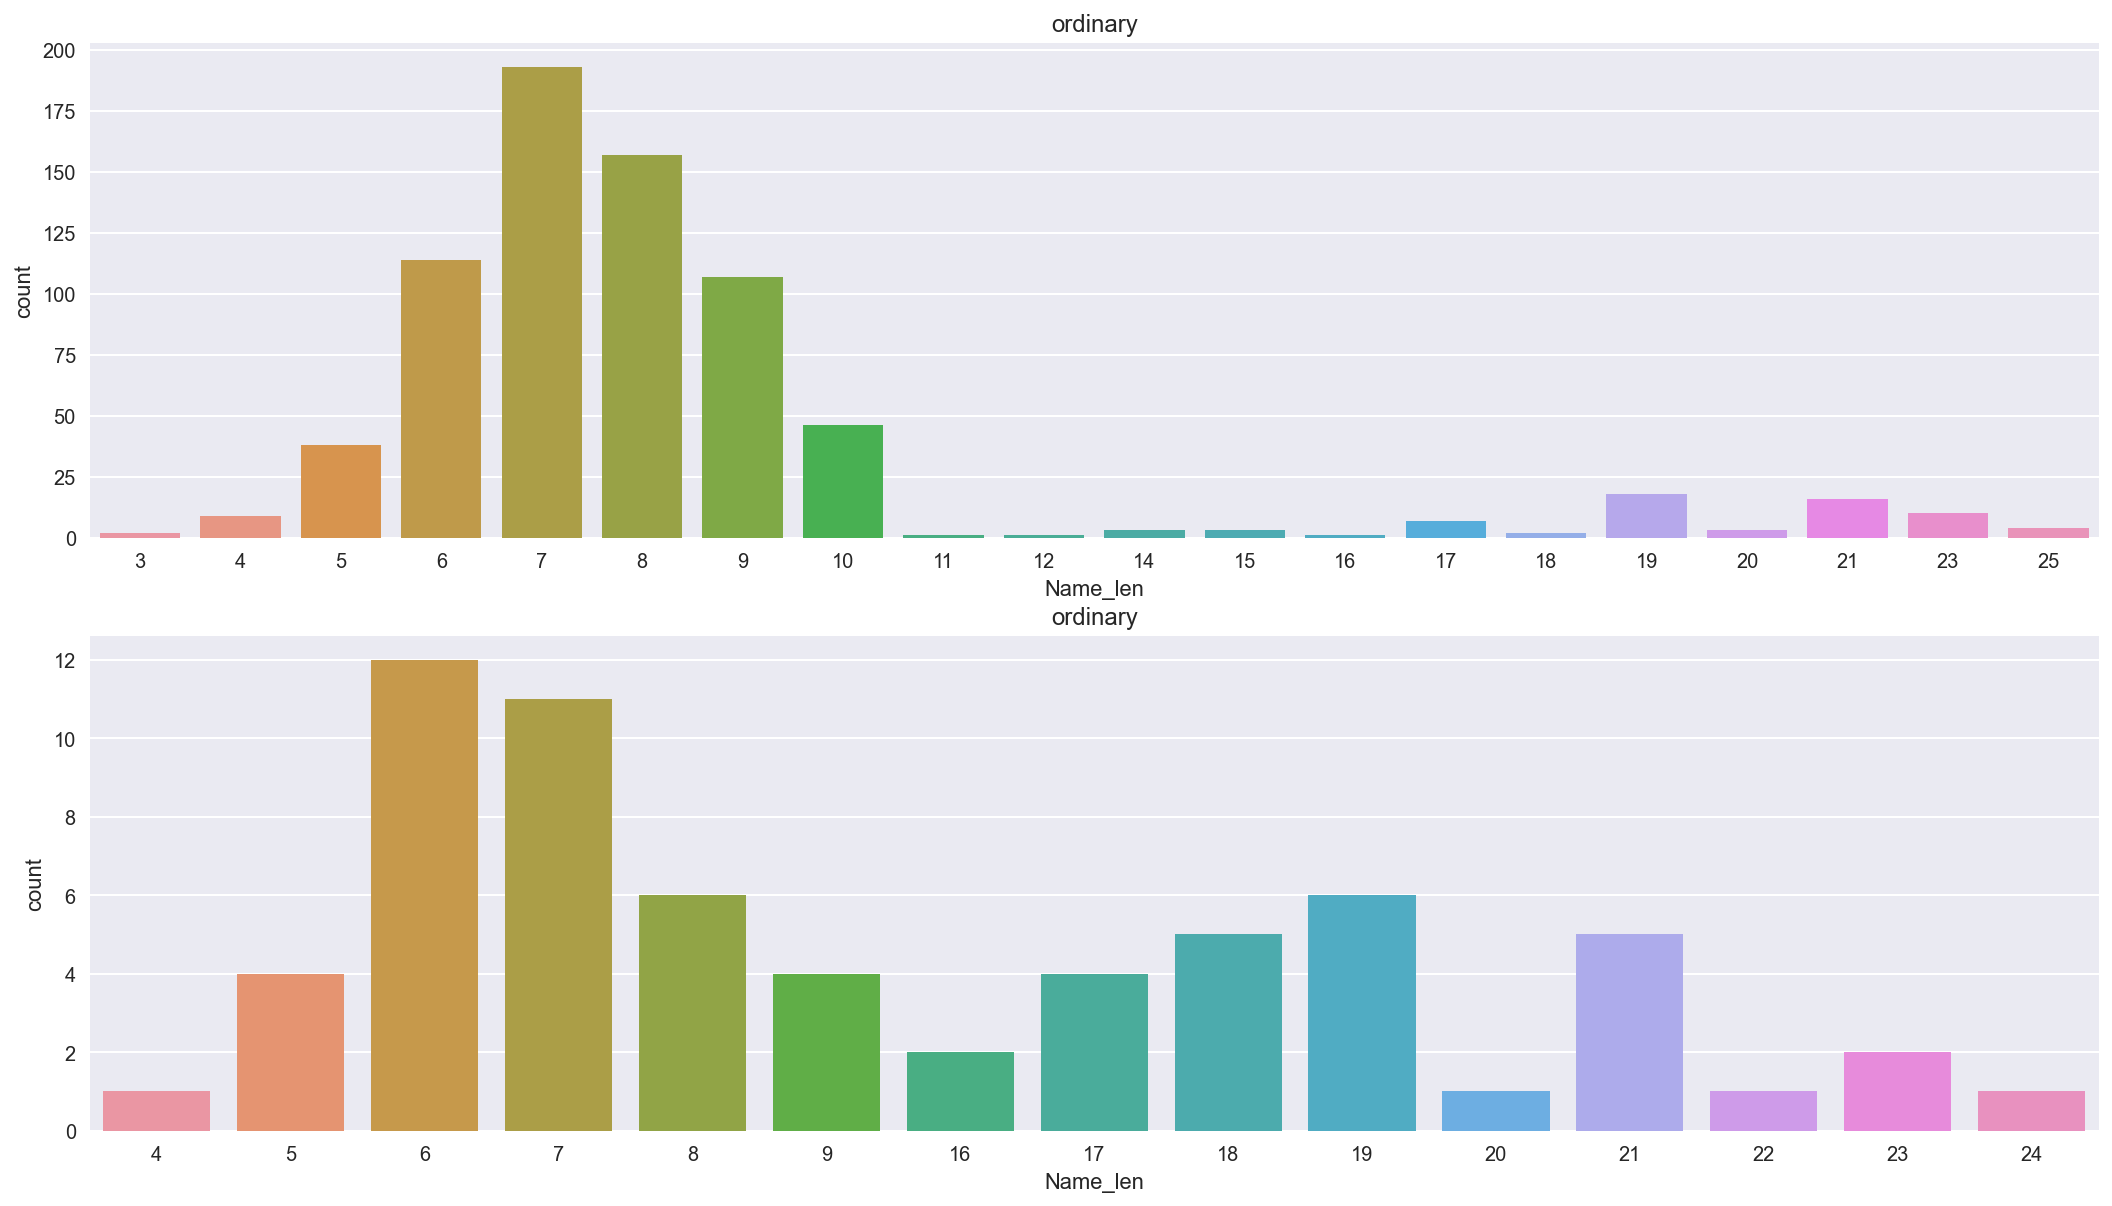

In [294]:
plt.figure(figsize=(18,10))
plt.subplot(211)
sns.countplot(data=ordinary,x='Name_len').set_title('ordinary')

plt.subplot(212)
sns.countplot(data=legendary,x='Name_len').set_title('ordinary')

In [295]:
len(legendary[legendary.Name_len>=16])

27

In [296]:
len(ordinary[ordinary.Name_len>=16])

61

In [297]:
pokemon['Name_len'] = pokemon.Name.apply(lambda x :len(x))

In [298]:
pokemon['Name_long'] = pokemon.Name_len.apply(lambda x: x>=16)

In [299]:
pokemon['Name']=pokemon['Name'].str.replace(' ','')

In [300]:
pokemon['Name_isalpha']=pokemon.Name.apply(lambda x: x.isalpha())

In [301]:
pokemon[pokemon.Name_isalpha == False][['Name']]

,Name
34,Nidoran♀
37,Nidoran♂
90,Farfetch'd
131,Mr.Mime
252,Porygon2
270,Ho-oh
487,MimeJr.
525,Porygon-Z
794,Zygarde50%Forme


In [302]:
pokemon = pokemon.replace(to_replace="Nidoran♀", value="Nidoran X")
pokemon = pokemon.replace(to_replace="Nidoran♂", value="Nidoran Y")
pokemon = pokemon.replace(to_replace="Farfetch'd", value="Farfetchd")
pokemon = pokemon.replace(to_replace="Mr.Mime", value="Mr Mime")
pokemon = pokemon.replace(to_replace="Porygon2", value="Porygon")
pokemon = pokemon.replace(to_replace="Ho-oh", value="Ho Oh")
pokemon = pokemon.replace(to_replace="MimeJr.", value="Mime Jr")
pokemon = pokemon.replace(to_replace="Porygon-Z", value="Porygon Z")
pokemon = pokemon.replace(to_replace="Zygarde50%Forme", value="Zygarde Forme")

pokemon.loc[[34, 37, 90, 131, 252, 270, 487, 525, 794]]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Name_len,Name_long,Name_isalpha
34,29,Nidoran X,Poison,NaN,275,55,47,52,40,40,41,1,False,8,False,False
37,32,Nidoran Y,Poison,NaN,273,46,57,40,40,40,50,1,False,8,False,False
90,83,Farfetchd,Normal,Flying,352,52,65,55,58,62,60,1,False,10,False,False
131,122,Mr Mime,Psychic,Fairy,460,40,45,65,100,120,90,1,False,8,False,False
252,233,Porygon,Normal,NaN,515,85,80,90,105,95,60,2,False,8,False,False
270,250,Ho Oh,Fire,Flying,680,106,130,90,110,154,90,2,True,5,False,False
487,439,Mime Jr,Psychic,Fairy,310,20,25,45,70,90,60,4,False,8,False,False
525,474,Porygon Z,Normal,NaN,535,85,80,70,135,75,90,4,False,9,False,False
794,718,Zygarde Forme,Dragon,Ground,600,108,100,121,81,95,95,6,True,16,True,False


In [303]:
pokemon['Name']=pokemon['Name'].str.replace(' ','')
pokemon['Name_isalpha']=pokemon.Name.apply(lambda x: x.isalpha())
pokemon[pokemon["Name_isalpha"] == False]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Name_len,Name_long,Name_isalpha


In [304]:
types = pokemon['Type 1'].unique()

In [305]:
for t in types:
    pokemon[t] = (pokemon["Type 1"] == t) | (pokemon["Type 2"] == t)
    


In [306]:
#pokemon[[["Type 1", "Type 2"] + types][0]].head()

In [307]:
pokemon

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,...,Fairy,Fighting,Psychic,Rock,Ghost,Ice,Dragon,Dark,Steel,Flying
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,...,False,False,False,False,False,False,False,False,False,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,...,False,False,False,False,False,False,False,False,False,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,...,False,False,False,False,False,False,False,False,False,False
3,3,VenusaurMegaVenusaur,Grass,Poison,625,80,100,123,122,120,...,False,False,False,False,False,False,False,False,False,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,...,True,False,False,True,False,False,False,False,False,False
796,719,DiancieMegaDiancie,Rock,Fairy,700,50,160,110,160,110,...,True,False,False,True,False,False,False,False,False,False
797,720,HoopaHoopaConfined,Psychic,Ghost,600,80,110,60,150,130,...,False,False,True,False,True,False,False,False,False,False
798,720,HoopaHoopaUnbound,Psychic,Dark,680,80,160,60,170,130,...,False,False,True,False,False,False,False,True,False,False


# Model

In [308]:
original=pd.read_csv('C:\\Users\\Lee\\Desktop\\GIt\\AIFFEL_first\\FUNDAMENTALS\\pokemon\\pokemon.csv')

In [309]:
features = ['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation']

In [310]:
target = 'Legendary'

In [311]:
X = original[features]
y = original[target]

In [312]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [313]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=25)

In [314]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [315]:
from sklearn.metrics import confusion_matrix,classification_report
confusion_matrix(y_test, y_pred)

array([[144,   3],
       [  5,   8]], dtype=int64)

In [316]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.97      0.98      0.97       147
        True       0.73      0.62      0.67        13

    accuracy                           0.95       160
   macro avg       0.85      0.80      0.82       160
weighted avg       0.95      0.95      0.95       160



### Upgrade

In [317]:
pokemon.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary', 'Name_len',
       'Name_long', 'Name_isalpha', 'Grass', 'Fire', 'Water', 'Bug', 'Normal',
       'Poison', 'Electric', 'Ground', 'Fairy', 'Fighting', 'Psychic', 'Rock',
       'Ghost', 'Ice', 'Dragon', 'Dark', 'Steel', 'Flying'],
      dtype='object')

In [318]:
feature = ['Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation',  'Name_len',
       'Name_long',  'Grass', 'Fire', 'Water', 'Bug', 'Normal',
       'Poison', 'Electric', 'Ground', 'Fairy', 'Fighting', 'Psychic', 'Rock',
       'Ghost', 'Ice', 'Dragon', 'Dark', 'Steel', 'Flying']

In [319]:
len(feature)

28

In [325]:
X = pokemon[feature]
y = pokemon['Legendary']

In [326]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [327]:
model = DecisionTreeClassifier(random_state=25)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
confusion_matrix(y_test, y_pred)


array([[142,   5],
       [  2,  11]], dtype=int64)

In [328]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.99      0.97      0.98       147
        True       0.69      0.85      0.76        13

    accuracy                           0.96       160
   macro avg       0.84      0.91      0.87       160
weighted avg       0.96      0.96      0.96       160

